# 07 — Rate Enhancement Program Effectiveness

**Goal:** Show that HHSC's own data proves past wage interventions (ACRE/DCSE) had
limited impact, and the program has diverged from its original purpose.

**Data Source:**
- `rate-enhancement-evaluation-2024.pdf` — HHSC Evaluation of Rate Enhancement Programs
  (Rider 30(d), 88th Legislature), October 2024

**Key findings (preview):**
- Only 35% of HCS/TxHmL providers participate in ACRE — lowest of any program
- Wage differential for high-participation programs: **negligible** (1-4%)
- Where participation is low (HCS/TxHmL), differential reaches 16% — but causality is unclear
- $14.9M in recoupments (2019-20) — 19.2% of ICF/IID entities had funds clawed back
- HHSC itself concludes the program is "no longer needed as its original purpose is no longer applicable"
- Attendant base wage rose from $5.15 (2000) to $10.60 (2023) via 5 legislative actions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# Load all ACRE datasets
df_participation = pd.read_csv(PROCESSED / 'hhsc_acre_participation.csv')
df_funding = pd.read_csv(PROCESSED / 'hhsc_acre_program_funding.csv')
df_recoupments = pd.read_csv(PROCESSED / 'hhsc_acre_recoupments.csv')
df_wage_hist = pd.read_csv(PROCESSED / 'hhsc_acre_wage_history.csv')

---
## 1. Provider Participation Varies Wildly (source_observation)

HHSC's own Table 3 shows participation ranges from 35% (HCS/TxHmL) to 93% (nursing facilities).
IDD providers — the focus of our investigation — have the lowest uptake.

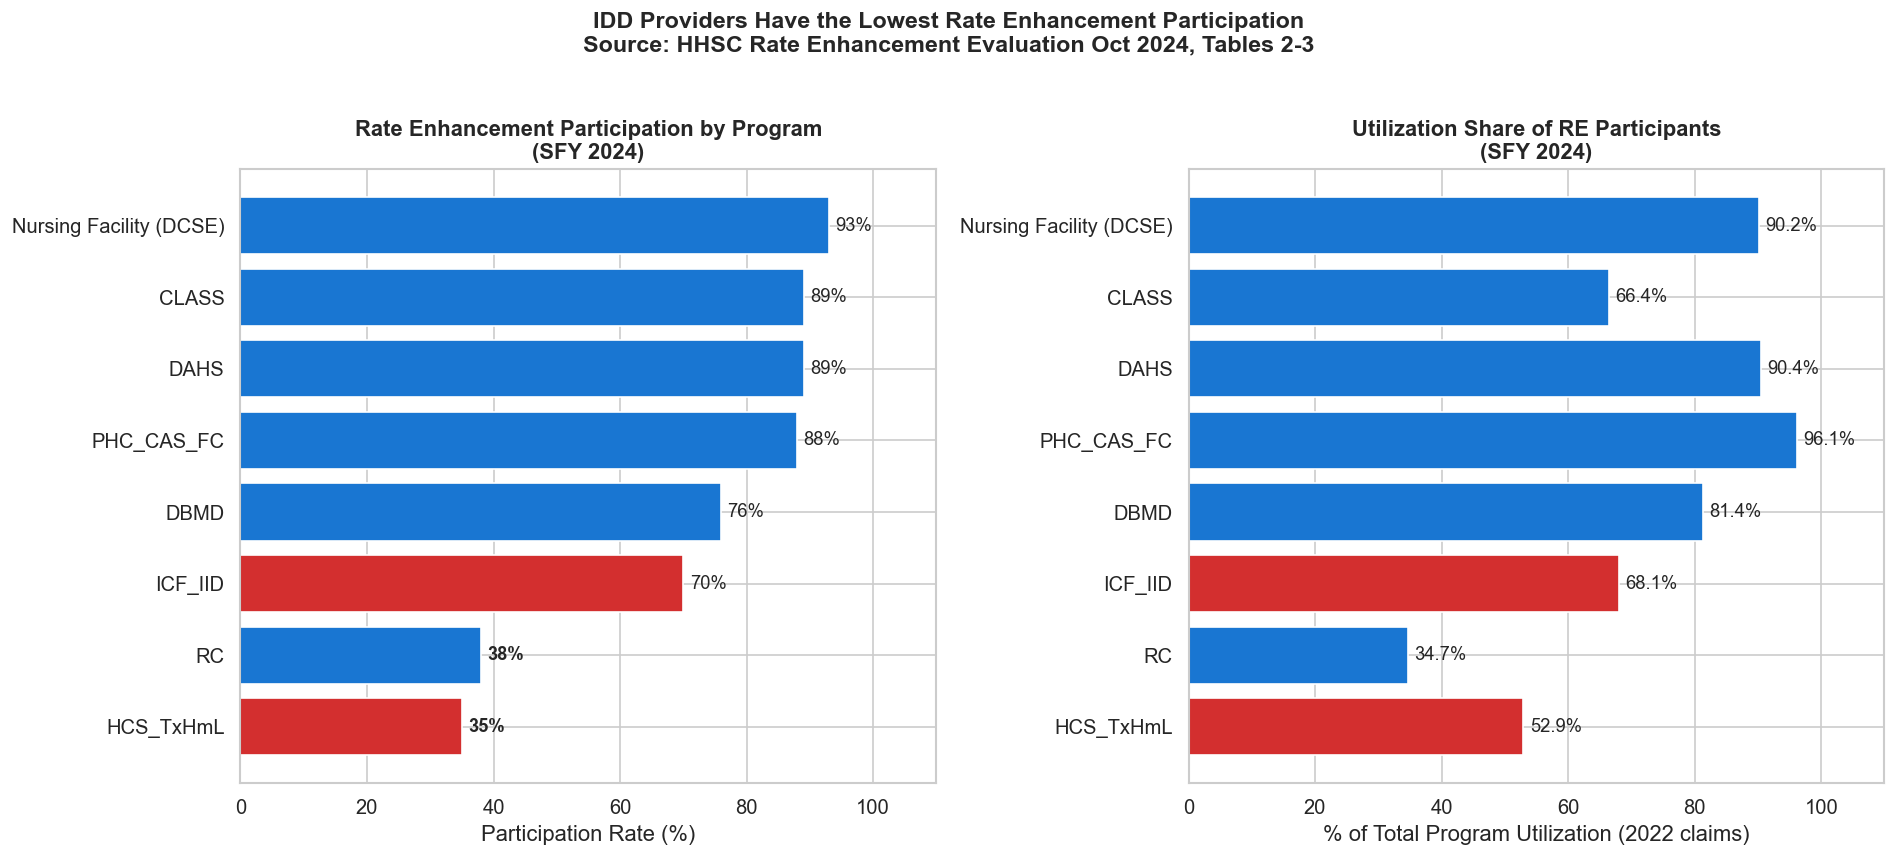


=== Participation Summary (source_observation) ===
  HCS_TxHmL                       241/696  = 35%  (utilization: 52.9%) ← IDD
  RC                               20/52   = 38%  (utilization: 34.7%)
  ICF_IID                          88/125  = 70%  (utilization: 68.1%) ← IDD
  DBMD                             37/49   = 76%  (utilization: 81.4%)
  PHC_CAS_FC                     1840/2096 = 88%  (utilization: 96.1%)
  DAHS                            252/282  = 89%  (utilization: 90.4%)
  CLASS                           103/116  = 89%  (utilization: 66.4%)
  Nursing Facility (DCSE)        1107/1187 = 93%  (utilization: 90.2%)


In [2]:
# Participation chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: participation rate
df_p = df_participation.sort_values('pct_participating', ascending=True)
colors = ['#d32f2f' if 'HCS' in p or 'ICF' in p else '#1976d2'
          for p in df_p['program']]

ax1.barh(df_p['program'], df_p['pct_participating'] * 100, color=colors)
for i, (_, row) in enumerate(df_p.iterrows()):
    ax1.text(row['pct_participating'] * 100 + 1, i,
             f"{row['pct_participating']:.0%}", va='center', fontsize=11,
             fontweight='bold' if row['pct_participating'] < 0.5 else 'normal')
ax1.set_xlabel('Participation Rate (%)')
ax1.set_title('Rate Enhancement Participation by Program\n(SFY 2024)',
              fontweight='bold')
ax1.set_xlim(0, 110)

# Right: utilization share
ax2.barh(df_p['program'], df_p['pct_utilization'] * 100, color=colors)
for i, (_, row) in enumerate(df_p.iterrows()):
    ax2.text(row['pct_utilization'] * 100 + 1, i,
             f"{row['pct_utilization']:.1%}", va='center', fontsize=11)
ax2.set_xlabel('% of Total Program Utilization (2022 claims)')
ax2.set_title('Utilization Share of RE Participants\n(SFY 2024)',
              fontweight='bold')
ax2.set_xlim(0, 110)

plt.suptitle('IDD Providers Have the Lowest Rate Enhancement Participation\n'
             'Source: HHSC Rate Enhancement Evaluation Oct 2024, Tables 2-3',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'acre_participation.png', bbox_inches='tight')
plt.show()

print("\n=== Participation Summary (source_observation) ===")
for _, row in df_p.iterrows():
    flag = " ← IDD" if 'HCS' in row['program'] or 'ICF' in row['program'] else ""
    print(f"  {row['program']:<30} "
          f"{row['participating_providers']:>4}/{row['total_contracted_providers']:<4} "
          f"= {row['pct_participating']:.0%}  "
          f"(utilization: {row['pct_utilization']:.1%}){flag}")

---
## 2. Wage Differential: Negligible Where It Matters Most (source_observation)

HHSC evaluated hourly wage differentials between participating and non-participating
providers. The finding is damning: where participation is high (most programs), the
wage difference is negligible (1-4%). The only meaningful differential (16%) is in
HCS/TxHmL — the program with *lowest* participation (35%).

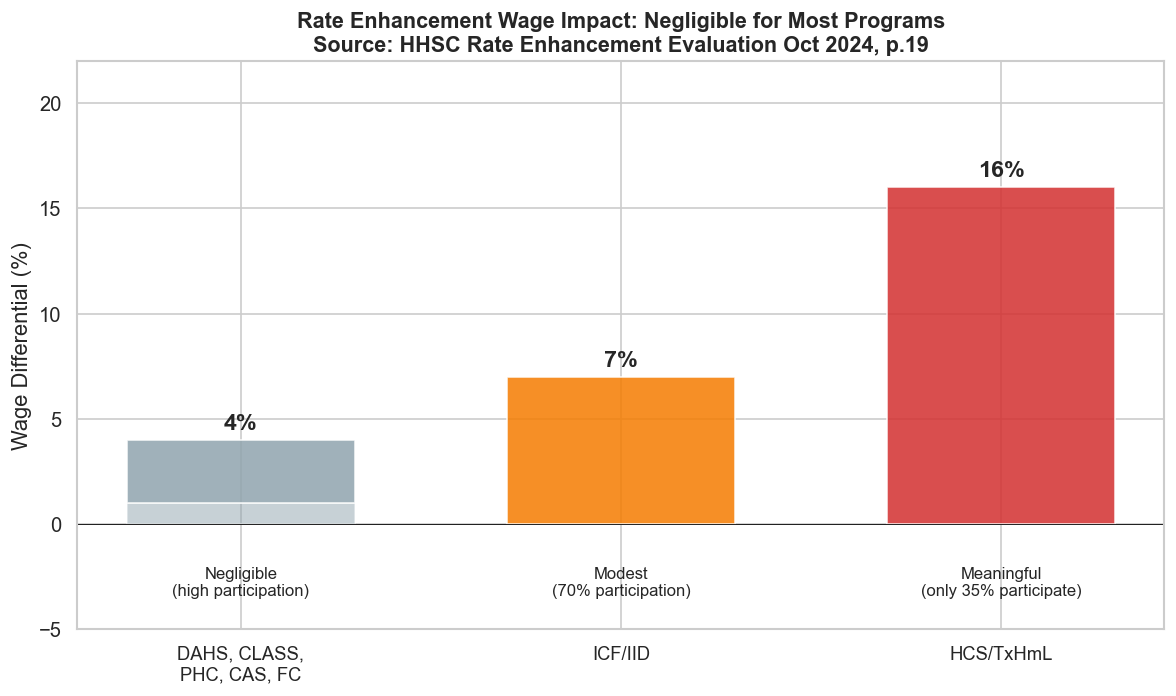


=== Wage Differential Summary (source_observation) ===
HHSC evaluated cost/accountability report data:
  DAHS, CLASS, PHC, CAS, FC:  1-4% differential (NEGLIGIBLE)
  ICF/IID:                    7% differential
  HCS/TxHmL:                  16% differential

Key insight: High participation correlates with negligible impact.
The program may simply be funding wages providers would pay anyway.


In [3]:
# Wage differential analysis
efficacy_data = [
    ('DAHS, CLASS,\nPHC, CAS, FC', 1, 4, 'Negligible\n(high participation)'),
    ('ICF/IID', 7, 7, 'Modest\n(70% participation)'),
    ('HCS/TxHmL', 16, 16, 'Meaningful\n(only 35% participate)'),
]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(efficacy_data))
width = 0.6

for i, (label, lo, hi, note) in enumerate(efficacy_data):
    color = '#d32f2f' if hi >= 10 else '#f57c00' if hi >= 5 else '#90a4ae'
    if lo == hi:
        ax.bar(i, hi, width, color=color, alpha=0.85)
    else:
        ax.bar(i, lo, width, color=color, alpha=0.5, label='Low' if i == 0 else '')
        ax.bar(i, hi - lo, width, bottom=lo, color=color, alpha=0.85)
    ax.text(i, hi + 0.5, f"{hi}%", ha='center', fontsize=14, fontweight='bold')
    ax.text(i, -2, note, ha='center', fontsize=10, va='top')

ax.set_xticks(x)
ax.set_xticklabels([d[0] for d in efficacy_data], fontsize=11)
ax.set_ylabel('Wage Differential (%)')
ax.set_title('Rate Enhancement Wage Impact: Negligible for Most Programs\n'
             'Source: HHSC Rate Enhancement Evaluation Oct 2024, p.19',
             fontweight='bold', fontsize=13)
ax.set_ylim(-5, 22)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(REPORTS / 'acre_wage_differential.png', bbox_inches='tight')
plt.show()

print("\n=== Wage Differential Summary (source_observation) ===")
print("HHSC evaluated cost/accountability report data:")
print("  DAHS, CLASS, PHC, CAS, FC:  1-4% differential (NEGLIGIBLE)")
print("  ICF/IID:                    7% differential")
print("  HCS/TxHmL:                  16% differential")
print("\nKey insight: High participation correlates with negligible impact.")
print("The program may simply be funding wages providers would pay anyway.")

---
## 3. Program Funding Growth vs Outcomes (source_observation)

Total rate enhancement funding grew from $199M (SFY 2019) to $306M (SFY 2024) —
a 54% increase. Yet HHSC's own evaluation found negligible wage impact.

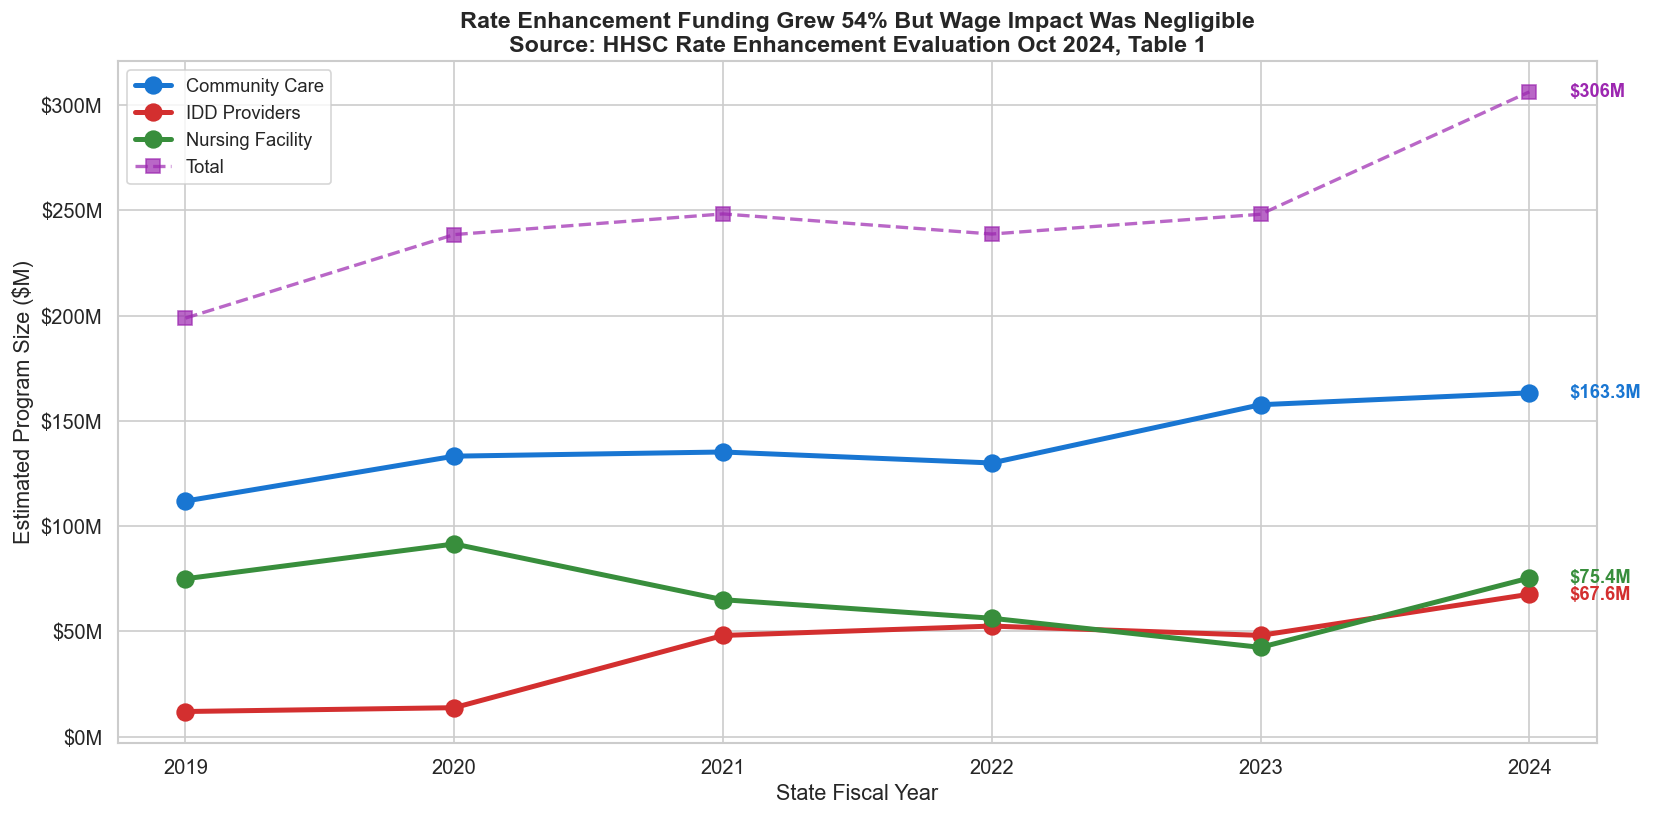


Total funding growth SFY 2019-2024: 54%
  SFY 2019: $198.8M
  SFY 2024: $306.3M

IDD provider funding growth: 467%
  SFY 2019: $11.9M → SFY 2024: $67.6M


In [4]:
# Program funding trend
fig, ax = plt.subplots(figsize=(14, 7))

provider_colors = {
    'Community Care': '#1976d2',
    'IDD Providers': '#d32f2f',
    'Nursing Facility': '#388e3c',
}

for ptype in df_funding['provider_type'].unique():
    data = df_funding[df_funding['provider_type'] == ptype].sort_values('state_fiscal_year')
    ax.plot(data['state_fiscal_year'], data['estimated_program_size'] / 1e6,
            'o-', color=provider_colors.get(ptype, '#666'),
            linewidth=3, markersize=10, label=ptype, zorder=4)
    last = data.iloc[-1]
    ax.text(last['state_fiscal_year'] + 0.15,
            last['estimated_program_size'] / 1e6,
            f"${last['estimated_program_size']/1e6:.1f}M",
            fontweight='bold', fontsize=11, va='center',
            color=provider_colors.get(ptype, '#666'))

# Total line
totals = df_funding.groupby('state_fiscal_year')['estimated_program_size'].sum()
ax.plot(totals.index, totals.values / 1e6, 's--', color='#9c27b0',
        linewidth=2, markersize=8, label='Total', alpha=0.7)
ax.text(totals.index[-1] + 0.15, totals.values[-1] / 1e6,
        f"${totals.values[-1]/1e6:.0f}M", color='#9c27b0',
        fontweight='bold', fontsize=11, va='center')

ax.set_xlabel('State Fiscal Year', fontsize=13)
ax.set_ylabel('Estimated Program Size ($M)', fontsize=13)
ax.set_title('Rate Enhancement Funding Grew 54% But Wage Impact Was Negligible\n'
             'Source: HHSC Rate Enhancement Evaluation Oct 2024, Table 1',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}M'))

plt.tight_layout()
plt.savefig(REPORTS / 'acre_funding_trend.png', bbox_inches='tight')
plt.show()

growth = (totals.iloc[-1] - totals.iloc[0]) / totals.iloc[0] * 100
print(f"\nTotal funding growth SFY 2019-2024: {growth:.0f}%")
print(f"  SFY 2019: ${totals.iloc[0]/1e6:.1f}M")
print(f"  SFY 2024: ${totals.iloc[-1]/1e6:.1f}M")
idd_2019 = df_funding[(df_funding['provider_type'] == 'IDD Providers') &
                       (df_funding['state_fiscal_year'] == 2019)]['estimated_program_size'].iloc[0]
idd_2024 = df_funding[(df_funding['provider_type'] == 'IDD Providers') &
                       (df_funding['state_fiscal_year'] == 2024)]['estimated_program_size'].iloc[0]
print(f"\nIDD provider funding growth: {(idd_2024/idd_2019 - 1)*100:.0f}%")
print(f"  SFY 2019: ${idd_2019/1e6:.1f}M → SFY 2024: ${idd_2024/1e6:.1f}M")

---
## 4. Recoupments: ICF/IID Providers Hit Hardest (source_observation)

When providers fail to spend rate enhancement funds on allowable expenses (wages, benefits),
HHSC claws back the money. ICF/IID providers had the highest recoupment rate: 19.2% of entities.

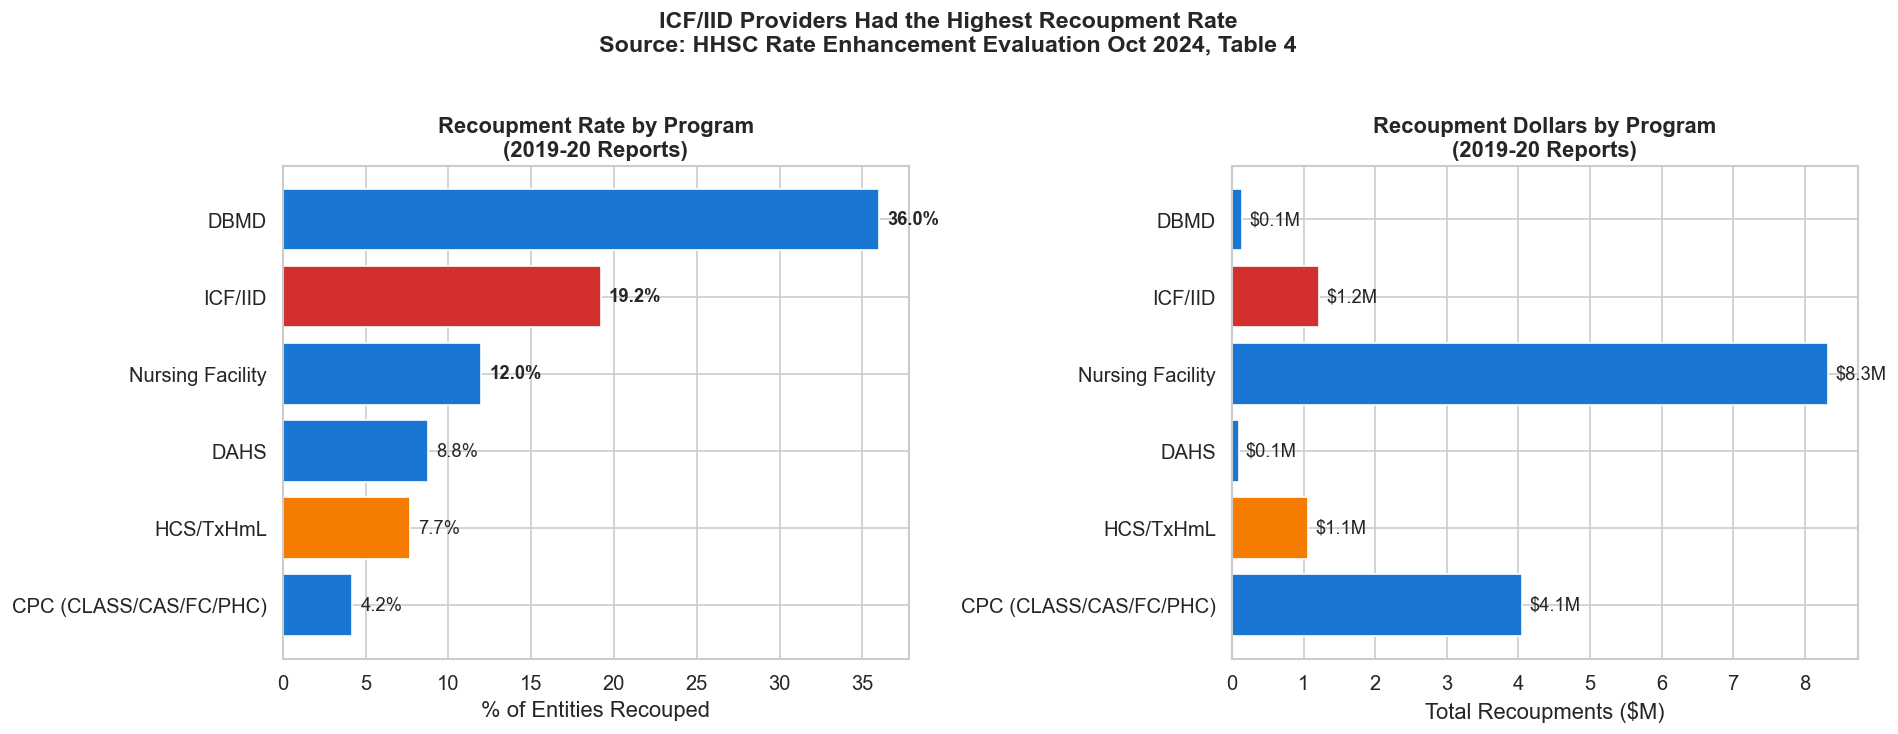


Total recoupments (2019-20): $14,894,648

By program:
  CPC (CLASS/CAS/FC/PHC)          89/2099 (4.2%) = $ 4,050,086
  HCS/TxHmL                       55/712  (7.7%) = $ 1,066,166
  DAHS                            43/490  (8.8%) = $    94,486
  Nursing Facility               138/1172 (12.0%) = $ 8,323,355
  ICF/IID                         25/130  (19.2%) = $ 1,219,442
  DBMD                             7/19   (36.0%) = $   141,113


In [5]:
# Recoupment analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_r = df_recoupments.sort_values('pct_recouped', ascending=True)
colors = ['#d32f2f' if 'ICF' in r else '#f57c00' if 'HCS' in r else '#1976d2'
          for r in df_r['report_type']]

# Left: recoupment rate
ax1.barh(df_r['report_type'], df_r['pct_recouped'] * 100, color=colors)
for i, (_, row) in enumerate(df_r.iterrows()):
    ax1.text(row['pct_recouped'] * 100 + 0.5, i,
             f"{row['pct_recouped']:.1%}", va='center', fontsize=11,
             fontweight='bold' if row['pct_recouped'] > 0.10 else 'normal')
ax1.set_xlabel('% of Entities Recouped')
ax1.set_title('Recoupment Rate by Program\n(2019-20 Reports)', fontweight='bold')

# Right: dollar amount
ax2.barh(df_r['report_type'], df_r['sum_recoupments'] / 1e6, color=colors)
for i, (_, row) in enumerate(df_r.iterrows()):
    ax2.text(row['sum_recoupments'] / 1e6 + 0.1, i,
             f"${row['sum_recoupments']/1e6:.1f}M", va='center', fontsize=11)
ax2.set_xlabel('Total Recoupments ($M)')
ax2.set_title('Recoupment Dollars by Program\n(2019-20 Reports)', fontweight='bold')

plt.suptitle('ICF/IID Providers Had the Highest Recoupment Rate\n'
             'Source: HHSC Rate Enhancement Evaluation Oct 2024, Table 4',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

total_recouped = df_recoupments['sum_recoupments'].sum()
print(f"\nTotal recoupments (2019-20): ${total_recouped:,.0f}")
print(f"\nBy program:")
for _, row in df_r.iterrows():
    print(f"  {row['report_type']:<30} "
          f"{row['count_recouped']:>3}/{row['count_entities']:<4} "
          f"({row['pct_recouped']:.1%}) = ${row['sum_recoupments']:>10,.0f}")

---
## 5. Attendant Base Wage History: 23 Years, 5 Increases (source_observation)

The attendant base wage — the state-defined minimum for personal attendant services —
has been raised only 5 times since its creation in 2000. The federal minimum wage has
been frozen at $7.25 since 2009, yet the program was originally designed as an
*incentive above* the federal minimum.

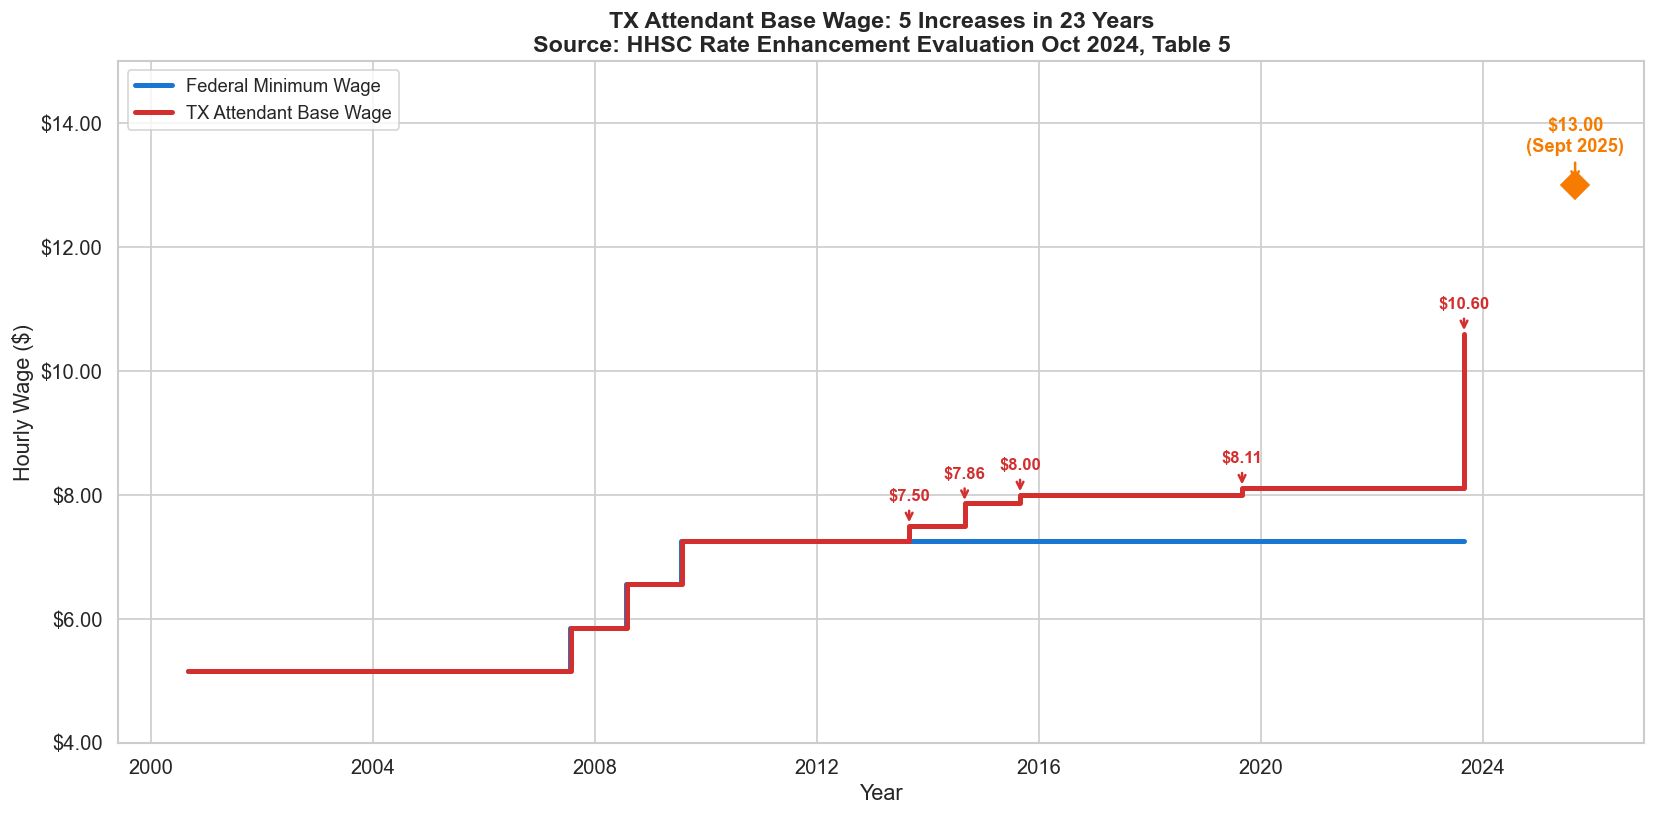


=== Attendant Base Wage History (source_observation) ===
  2000-09-01  Fed min: $5.15  Attendant: $5.15
  2007-07-24  Fed min: $5.85  Attendant: $5.15
  2007-08-01  Fed min: $5.85  Attendant: $5.85
  2008-07-24  Fed min: $6.55  Attendant: $5.85
  2008-08-01  Fed min: $6.55  Attendant: $6.55
  2009-07-24  Fed min: $7.25  Attendant: $6.55
  2009-08-01  Fed min: $7.25  Attendant: $7.25
  2013-09-01  Fed min: $7.25  Attendant: $7.50  [S.B. 1, 83rd Leg, 2013, Art II Sec 61]
  2014-09-01  Fed min: $7.25  Attendant: $7.86  [S.B. 1, 83rd Leg, 2013, Art II Sec 61]
  2015-09-01  Fed min: $7.25  Attendant: $8.00  [H.B. 1, 84th Leg, 2015, Art II Sec 47]
  2019-09-01  Fed min: $7.25  Attendant: $8.11  [H.B. 1, 86th Leg, 2019, Art II Rider 45]
  2023-09-01  Fed min: $7.25  Attendant: $10.60  [S.B. 1, 88th Leg, 2023, Art II Rider 30(a)]


In [6]:
# Attendant base wage history
fig, ax = plt.subplots(figsize=(14, 7))

df_w = df_wage_hist.copy()
df_w['effective_date'] = pd.to_datetime(df_w['effective_date'])

ax.step(df_w['effective_date'], df_w['federal_minimum_wage'],
        where='post', linewidth=3, color='#1976d2', label='Federal Minimum Wage')
ax.step(df_w['effective_date'], df_w['attendant_base_wage'],
        where='post', linewidth=3, color='#d32f2f', label='TX Attendant Base Wage')

# Annotate key legislative actions
annotations = df_w[df_w['legislative_citation'].notna()]
for _, row in annotations.iterrows():
    ax.annotate(f"${row['attendant_base_wage']:.2f}",
                xy=(row['effective_date'], row['attendant_base_wage']),
                xytext=(0, 15), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#d32f2f',
                ha='center',
                arrowprops=dict(arrowstyle='->', color='#d32f2f', lw=1.5))

# Add $13 target
import datetime
ax.plot(datetime.datetime(2025, 9, 1), 13.00, 'D', color='#f57c00',
        markersize=12, zorder=5)
ax.annotate('$13.00\n(Sept 2025)', xy=(datetime.datetime(2025, 9, 1), 13.00),
            xytext=(0, 20), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#f57c00', ha='center',
            arrowprops=dict(arrowstyle='->', color='#f57c00', lw=1.5))

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Hourly Wage ($)', fontsize=13)
ax.set_title('TX Attendant Base Wage: 5 Increases in 23 Years\n'
             'Source: HHSC Rate Enhancement Evaluation Oct 2024, Table 5',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.2f}'))
ax.set_ylim(4, 15)

plt.tight_layout()
plt.savefig(REPORTS / 'acre_wage_history.png', bbox_inches='tight')
plt.show()

print("\n=== Attendant Base Wage History (source_observation) ===")
for _, row in df_w.iterrows():
    cite = f"  [{row['legislative_citation']}]" if pd.notna(row['legislative_citation']) else ""
    print(f"  {row['effective_date'].strftime('%Y-%m-%d')}  "
          f"Fed min: ${row['federal_minimum_wage']:.2f}  "
          f"Attendant: ${row['attendant_base_wage']:.2f}{cite}")

---
## 6. Key Findings

| Finding | Value | Type | Source |
|---------|-------|------|--------|
| Nursing facility DCSE participation | 93% | source_observation | Table 2 |
| HCS/TxHmL ACRE participation | 35% — **lowest** | source_observation | Table 3 |
| ICF/IID ACRE participation | 70% | source_observation | Table 3 |
| Wage differential (most programs) | 1-4% (negligible) | source_observation | p.19 |
| Wage differential (HCS/TxHmL) | 16% | source_observation | p.19 |
| Total recoupments (2019-20) | $14.9M | source_observation | Table 4 |
| ICF/IID recoupment rate | 19.2% of entities | source_observation | Table 4 |
| Total program funding (SFY 2024) | $306M | source_observation | Table 1 |
| Funding growth (SFY 2019-2024) | +54% | derived_estimate | Table 1 calc |
| Attendant base wage increases | 5 in 23 years | source_observation | Table 5 |

**Bottom line:** HHSC's own evaluation reveals that the Rate Enhancement program has
become a mechanism for funding *baseline* wages rather than providing *enhanced*
compensation. The agency itself concludes the program "is no longer needed as its
original purpose is no longer applicable." Advocacy organizations report that providers
use ACRE funds just to meet the attendant base wage — not to offer the bonuses,
retention raises, or benefits the program was designed to incentivize.

For IDD providers specifically:
- Only 35% of HCS/TxHmL providers participate (vs 93% of nursing facilities)
- 19.2% of ICF/IID entities had funds recouped — suggesting compliance burden
  deters small providers from participating
- The $10.60→$13.00 base wage increase may make ACRE even less relevant,
  as the base rate now exceeds what ACRE was designed to supplement